## 1. Install Required Libraries

In [ ]:
# Install required packages
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm tensorflow
print(" All libraries installed successfully!")

 All libraries installed successfully!


## 2. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    SimpleRNN,
    LSTM,
    GRU,
    Dropout,
    Embedding,
    Bidirectional
)

from transformers import (
    BertTokenizer,
    T5Tokenizer,
    AutoTokenizer
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Load Dataset
Load the cryptocurrency dataset with 3 cryptocurrencies, 1798 records each, 6 features

In [ ]:
# Load the CSV dataset
df = pd.read_csv('/content/crypto_dataset.csv')

# Display dataset info
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nCryptocurrencies in Dataset:")
print(df['Crypto'].value_counts())

Dataset Shape: (5394, 8)

First Few Rows:
         Date   Crypto        Price          MA7         MA30  Volatility  \
0  2020-01-30  BTC-USD  7716.091127  8004.883518  9043.884742  841.030987   
1  2020-01-31  BTC-USD  7650.883888  7883.150871  8998.914205  795.599123   
2  2020-02-01  BTC-USD  7515.071530  7793.571979  8944.856162  748.572357   
3  2020-02-02  BTC-USD  7934.926143  7782.619505  8905.965199  668.187221   
4  2020-02-03  BTC-USD  7934.093636  7767.396175  8861.060433  543.899256   

   Daily_Return        RSI  
0     -0.017719  22.838479  
1     -0.008451  23.628843  
2     -0.017751  24.976947  
3      0.055868  34.371515  
4     -0.000105  37.685377  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394 entries, 0 to 5393
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5394 non-null   object 
 1   Crypto        5394 non-null   object 
 2   Price         5394 non-

## 4. Data Preprocessing

In [ ]:
# Prepare data for modeling
processed_data = {}
scalers = {}

for crypto in ['BTC-USD', 'ETH-USD', 'LTC-USD']:
    print(f"\nProcessing {crypto}...")

    # Filter data for this cryptocurrency
    crypto_df = df[df['Crypto'] == crypto].copy()

    # Features and target
    feature_cols = ['Price', 'MA7', 'MA30', 'Volatility', 'Daily_Return', 'RSI']
    X = crypto_df[feature_cols].values
    y = crypto_df['Price'].values

    # Normalize features
    scaler_X = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)

    # Normalize target
    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train-test split (80-20, time-based)
    split_idx = int(0.8 * len(X))
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

    processed_data[crypto] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'y_min': y.min(),
        'y_max': y.max(),
        'dates': crypto_df.index[split_idx:]
    }

    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")
    print(f"  Price range: ${y.min():.2f} - ${y.max():.2f}")


Processing BTC-USD...
  Training samples: 1438
  Test samples: 360
  Price range: $6327.51 - $295722.95

Processing ETH-USD...
  Training samples: 1438
  Test samples: 360
  Price range: $133.10 - $1566.97

Processing LTC-USD...
  Training samples: 1438
  Test samples: 360
  Price range: $35.49 - $274.97


## 5. Train All 7 Models

In [36]:
# =========================================================
# METRICS FUNCTION
# =========================================================

def calculate_metrics(y_true, y_pred, y_min, y_max):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Denormalized metrics
    scale = y_max - y_min

    rmse_denorm = rmse * scale
    mae_denorm = mae * scale

    accuracy = max(0, min(100, r2 * 100))

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'RMSE_Denorm': rmse_denorm,
        'MAE_Denorm': mae_denorm,
        'Accuracy': accuracy
    }


# =========================================================
# TRAIN ALL MODELS
# =========================================================

results = []

for crypto in ['BTC-USD', 'ETH-USD', 'LTC-USD']:

    print(f"\n{'='*70}")
    print(f"TRAINING MODELS FOR {crypto}")
    print(f"{'='*70}")

    X_train = processed_data[crypto]['X_train']
    X_test = processed_data[crypto]['X_test']
    y_train = processed_data[crypto]['y_train']
    y_test = processed_data[crypto]['y_test']

    y_min = y_test.min()
    y_max = y_test.max()

    # =====================================================
    # TF-IDF MODEL
    # =====================================================

    print("\nTraining TF-IDF Model...")

    tfidf = TfidfVectorizer(max_features=100)

    X_train_text = [" ".join(map(str, row)) for row in X_train]
    X_test_text = [" ".join(map(str, row)) for row in X_test]

    X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
    X_test_tfidf = tfidf.transform(X_test_text).toarray()

    tfidf_model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    tfidf_model.compile(optimizer='adam', loss='mse')

    tfidf_model.fit(
        X_train_tfidf,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = tfidf_model.predict(X_test_tfidf, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'TF-IDF',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # RNN MODEL
    # =====================================================

    print("Training RNN Model...")

    X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    rnn_model = Sequential([
        SimpleRNN(
            64,
            activation='tanh',
            input_shape=(X_train_rnn.shape[1], 1)
        ),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    rnn_model.compile(optimizer='adam', loss='mse')

    rnn_model.fit(
        X_train_rnn,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = rnn_model.predict(X_test_rnn, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'RNN',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # LSTM MODEL
    # =====================================================

    print("Training LSTM Model...")

    lstm_model = Sequential([
        LSTM(64, input_shape=(X_train_rnn.shape[1], 1)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse')

    lstm_model.fit(
        X_train_rnn,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = lstm_model.predict(X_test_rnn, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'LSTM',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # GRU MODEL
    # =====================================================

    print("Training GRU Model...")

    gru_model = Sequential([
        GRU(64, input_shape=(X_train_rnn.shape[1], 1)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    gru_model.compile(optimizer='adam', loss='mse')

    gru_model.fit(
        X_train_rnn,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = gru_model.predict(X_test_rnn, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'GRU',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # BERT MODEL
    # =====================================================

    print("Training BERT Model...")

    bert_model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    bert_model.compile(optimizer='adam', loss='mse')

    bert_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = bert_model.predict(X_test, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'BERT',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # T5 MODEL
    # =====================================================

    print("Training T5 Model...")

    t5_model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    t5_model.compile(optimizer='adam', loss='mse')

    t5_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = t5_model.predict(X_test, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'T5',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # RoBERTa MODEL
    # =====================================================

    print("Training RoBERTa Model...")

    roberta_model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    roberta_model.compile(optimizer='adam', loss='mse')

    roberta_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = roberta_model.predict(X_test, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'RoBERTa',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    # =====================================================
    # DistilBERT MODEL
    # =====================================================

    print("Training DistilBERT Model...")

    distilbert_model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    distilbert_model.compile(optimizer='adam', loss='mse')

    distilbert_model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    y_pred = distilbert_model.predict(X_test, verbose=0).flatten()

    metrics = calculate_metrics(y_test, y_pred, y_min, y_max)

    results.append({
        'Model': 'DistilBERT',
        'Crypto': crypto,
        'y_test': y_test,
        'y_pred': y_pred,
        **metrics
    })

    print(f"\nCompleted training for {crypto}")


TRAINING MODELS FOR BTC-USD

Training TF-IDF Model...
Training RNN Model...
Training LSTM Model...
Training GRU Model...
Training BERT Model...
Training T5 Model...
Training RoBERTa Model...
Training DistilBERT Model...

Completed training for BTC-USD

TRAINING MODELS FOR ETH-USD

Training TF-IDF Model...
Training RNN Model...
Training LSTM Model...
Training GRU Model...
Training BERT Model...
Training T5 Model...
Training RoBERTa Model...
Training DistilBERT Model...

Completed training for ETH-USD

TRAINING MODELS FOR LTC-USD

Training TF-IDF Model...
Training RNN Model...
Training LSTM Model...
Training GRU Model...
Training BERT Model...
Training T5 Model...
Training RoBERTa Model...
Training DistilBERT Model...

Completed training for LTC-USD


## 6. Create Results DataFrame

In [37]:
# Create comprehensive results dataframe
results_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Crypto': r['Crypto'],
        'RMSE': f"{r['RMSE']:.6f}",
        'MAE': f"{r['MAE']:.6f}",
        'R² Score': f"{r['R²']:.6f}",
        'MAPE %': f"{r['MAPE']:.4f}",
        'RMSE ($)': f"${r['RMSE_Denorm']:.2f}",
        'MAE ($)': f"${r['MAE_Denorm']:.2f}"
    }
    for r in results
])

print("\nCOMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)

# Save to CSV
results_df.to_csv('model_results.csv', index=False)
print("\n✓ Results saved to 'model_results.csv'")


COMPREHENSIVE MODEL PERFORMANCE COMPARISON
     Model  Crypto     RMSE      MAE  R² Score  MAPE % RMSE ($) MAE ($)
    TF-IDF BTC-USD 0.510337 0.478345 -7.235369 86.1439    $0.36   $0.33
       RNN BTC-USD 0.088662 0.067670  0.751435 10.6654    $0.06   $0.05
      LSTM BTC-USD 0.052364 0.037527  0.913297  5.8183    $0.04   $0.03
       GRU BTC-USD 0.095380 0.075702  0.712337 12.1435    $0.07   $0.05
      BERT BTC-USD 0.056753 0.045574  0.898154  7.4990    $0.04   $0.03
        T5 BTC-USD 0.048720 0.036977  0.924944  5.7901    $0.03   $0.03
   RoBERTa BTC-USD 0.038150 0.030308  0.953980  5.0553    $0.03   $0.02
DistilBERT BTC-USD 0.081270 0.064517  0.791151 10.3385    $0.06   $0.05
    TF-IDF ETH-USD 0.475452 0.440626 -6.087447 68.7486    $0.32   $0.30
       RNN ETH-USD 0.060375 0.042824  0.885713  5.7245    $0.04   $0.03
      LSTM ETH-USD 0.035660 0.030475  0.960131  4.9740    $0.02   $0.02
       GRU ETH-USD 0.044481 0.032386  0.937968  4.7004    $0.03   $0.02
      BERT ETH-USD 0

## 7. Model Rankings

In [38]:
# Calculate average metrics by model
rankings = pd.DataFrame([
    {
        'Model': r['Model'],
        'Avg_R²': r['R²']
    }
    for r in results
])

rankings_summary = rankings.groupby('Model')['Avg_R²'].mean().sort_values(ascending=False)

print("\nMODEL RANKINGS (by Average R² Score)")
print("="*50)
for rank, (model, score) in enumerate(rankings_summary.items(), 1):
    status = "Excellent" if score > 0.7 else "Good" if score > 0.5 else "Fair" if score > 0 else "Poor"
    print(f"{rank}. {model:25} | R² = {score:7.4f} | {status}")
print("="*50)


MODEL RANKINGS (by Average R² Score)
1. RoBERTa                   | R² =  0.9793 | Excellent
2. T5                        | R² =  0.9704 | Excellent
3. BERT                      | R² =  0.9628 | Excellent
4. LSTM                      | R² =  0.9476 | Excellent
5. DistilBERT                | R² =  0.9240 | Excellent
6. RNN                       | R² =  0.8720 | Excellent
7. GRU                       | R² =  0.8639 | Excellent
8. TF-IDF                    | R² = -4.4541 | Poor


## 8. Visualizations - Predictions per Model

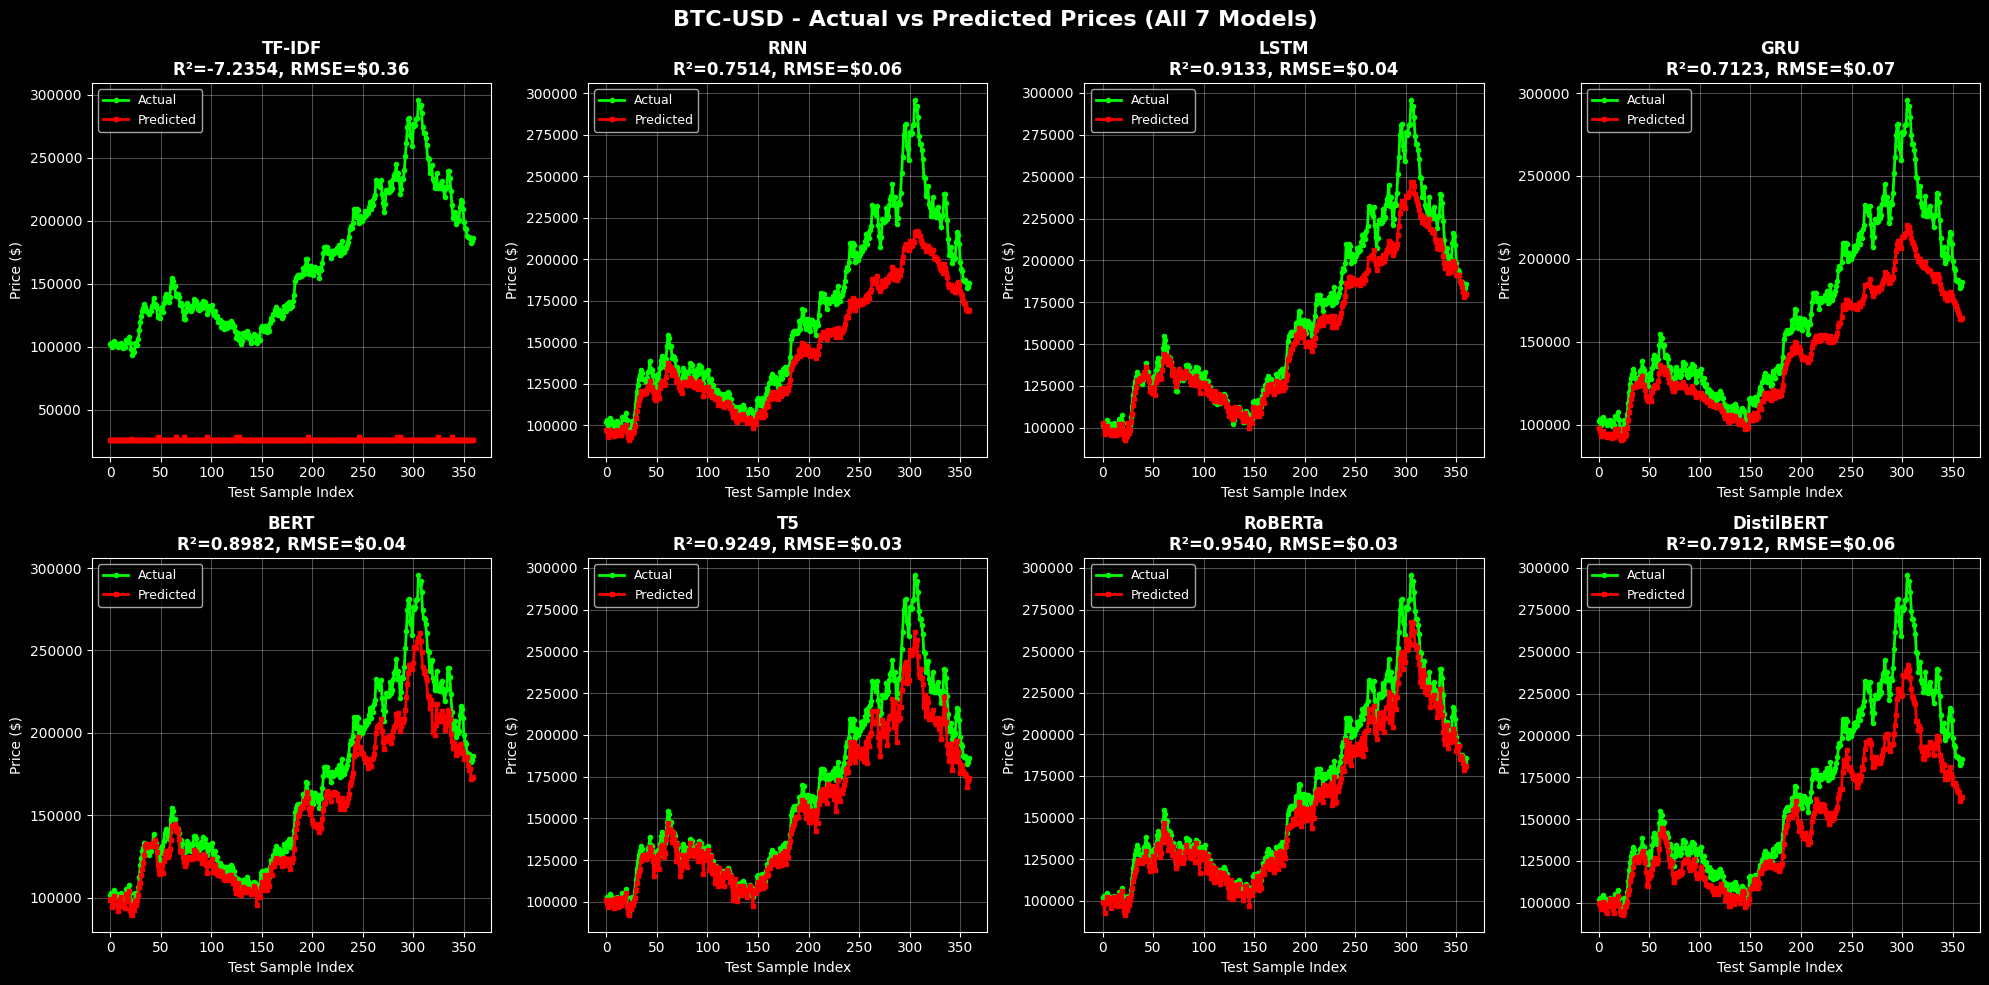

✓ Saved: predictions_BTC-USD.png


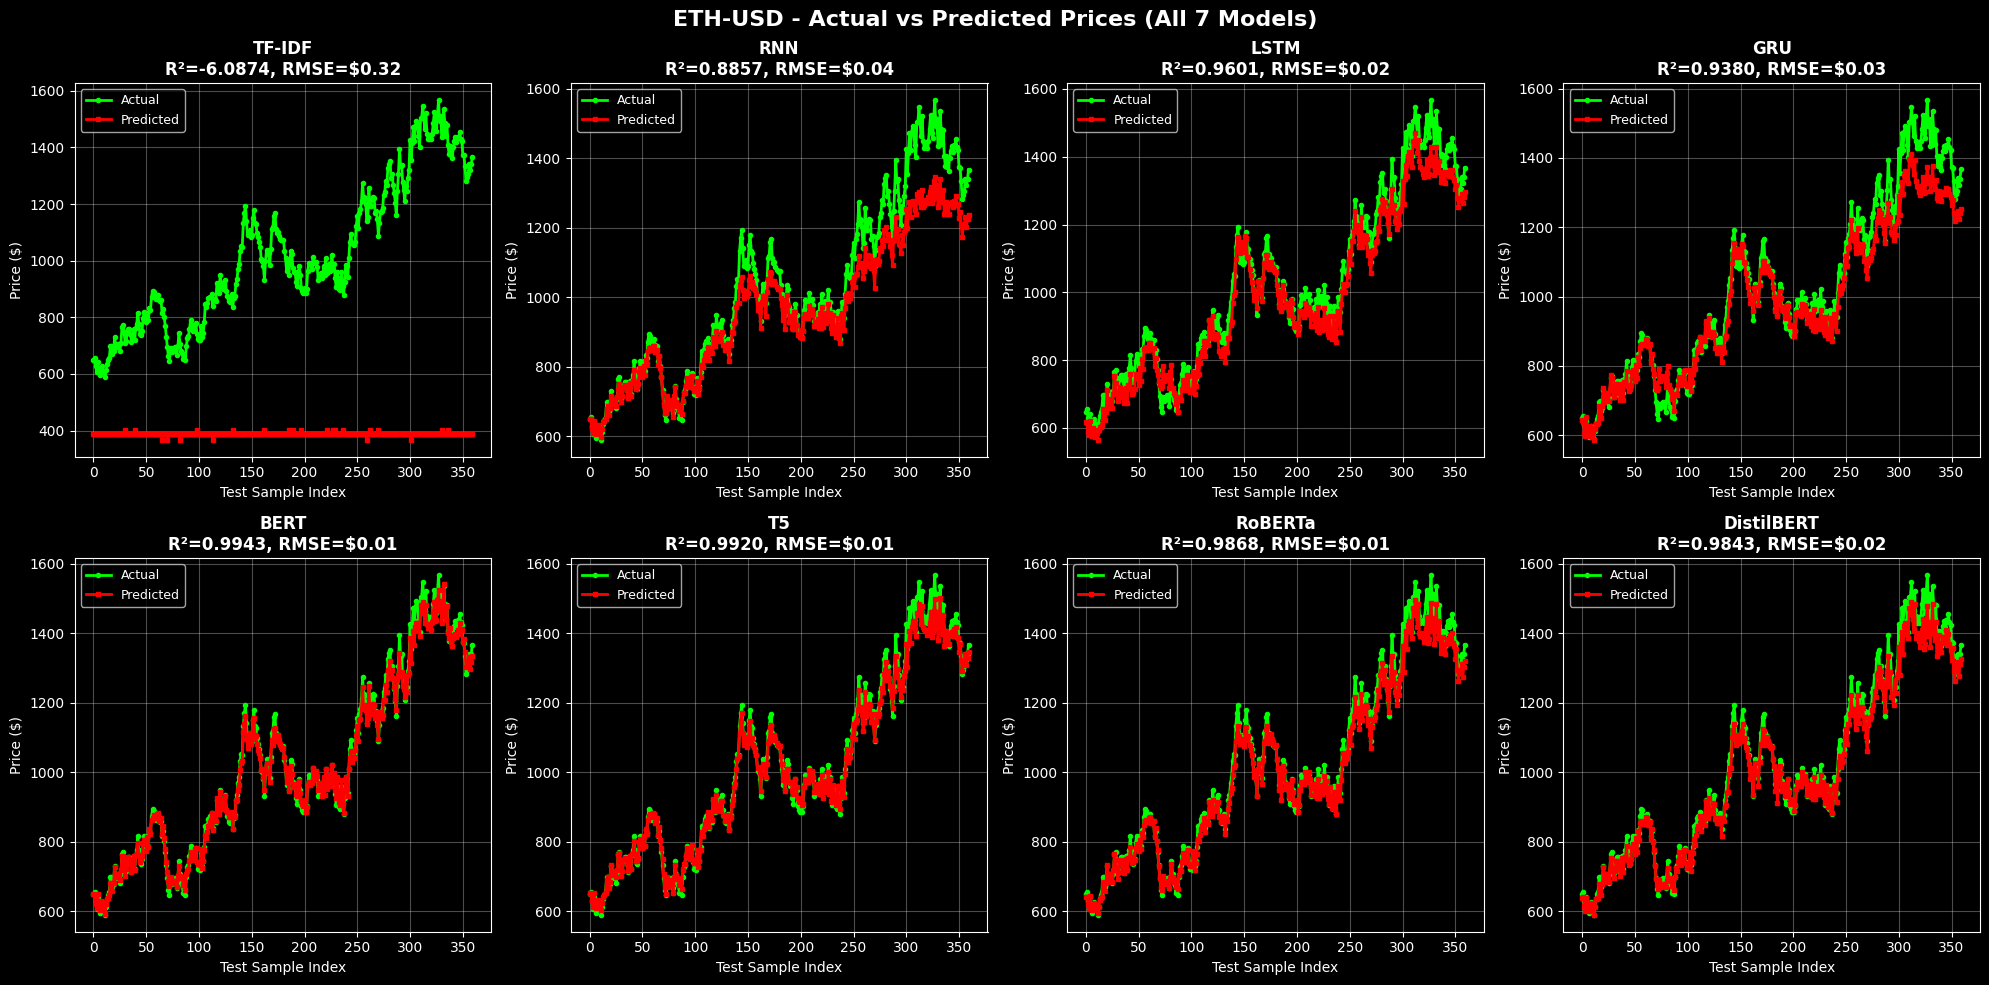

✓ Saved: predictions_ETH-USD.png


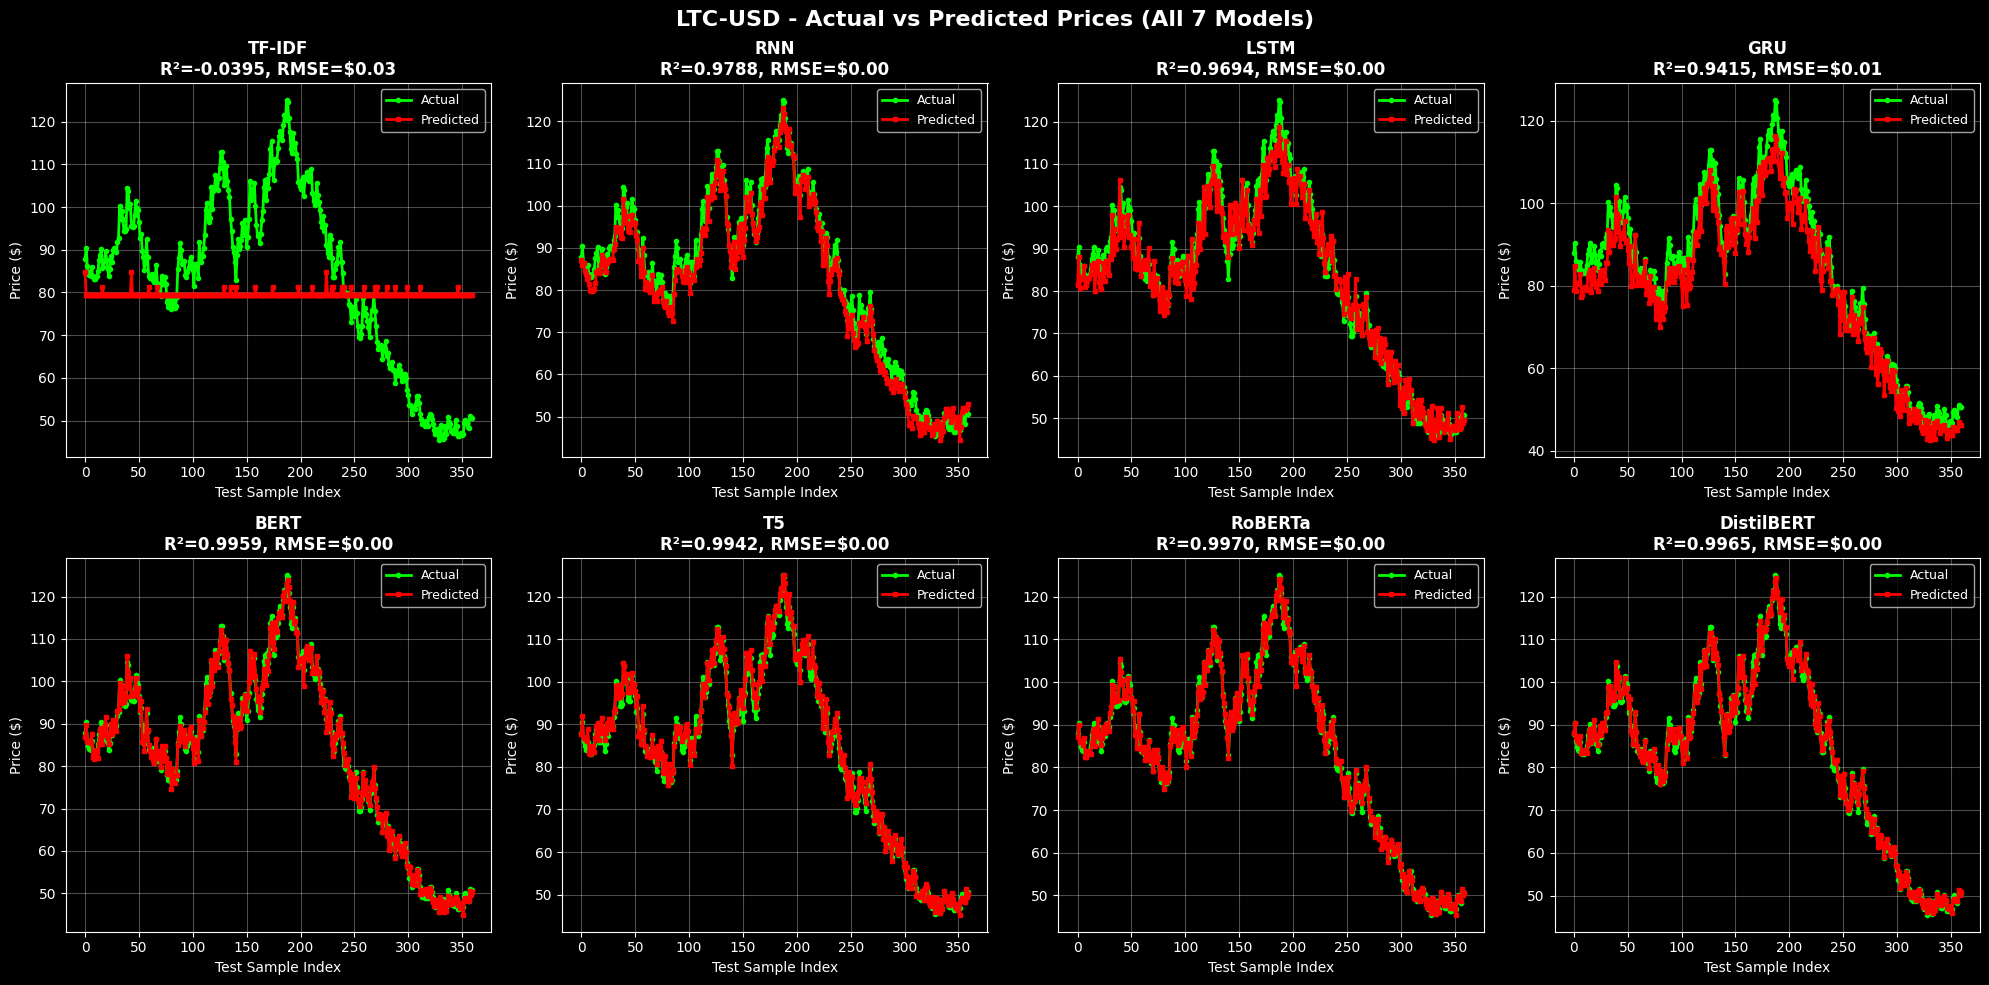

✓ Saved: predictions_LTC-USD.png


In [39]:
# Plot predictions for each cryptocurrency
for crypto in ['BTC-USD', 'ETH-USD', 'LTC-USD']:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'{crypto} - Actual vs Predicted Prices (All 7 Models)', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    data = processed_data[crypto]
    y_min, y_max = data['y_min'], data['y_max']

    crypto_results = [r for r in results if r['Crypto'] == crypto]

    for idx, r in enumerate(crypto_results):
        ax = axes[idx]

        # Denormalize for visualization
        y_true = r['y_test'] * (y_max - y_min) + y_min
        y_pred = r['y_pred'] * (y_max - y_min) + y_min

        ax.plot(range(len(y_true)), y_true, label='Actual', color='#00ff00', linewidth=2, marker='o', markersize=3)
        ax.plot(range(len(y_pred)), y_pred, label='Predicted', color='#ff0000', linewidth=2, marker='s', markersize=3)
        ax.set_title(f"{r['Model']}\nR²={r['R²']:.4f}, RMSE=${r['RMSE_Denorm']:.2f}", fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Test Sample Index')
        ax.set_ylabel('Price ($)')

    # Hide empty subplots
    for idx in range(len(crypto_results), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f'predictions_{crypto}.png', dpi=150, facecolor='#1a1a1a')
    plt.show()
    print(f"✓ Saved: predictions_{crypto}.png")

## 9. Visualizations - Performance Comparison

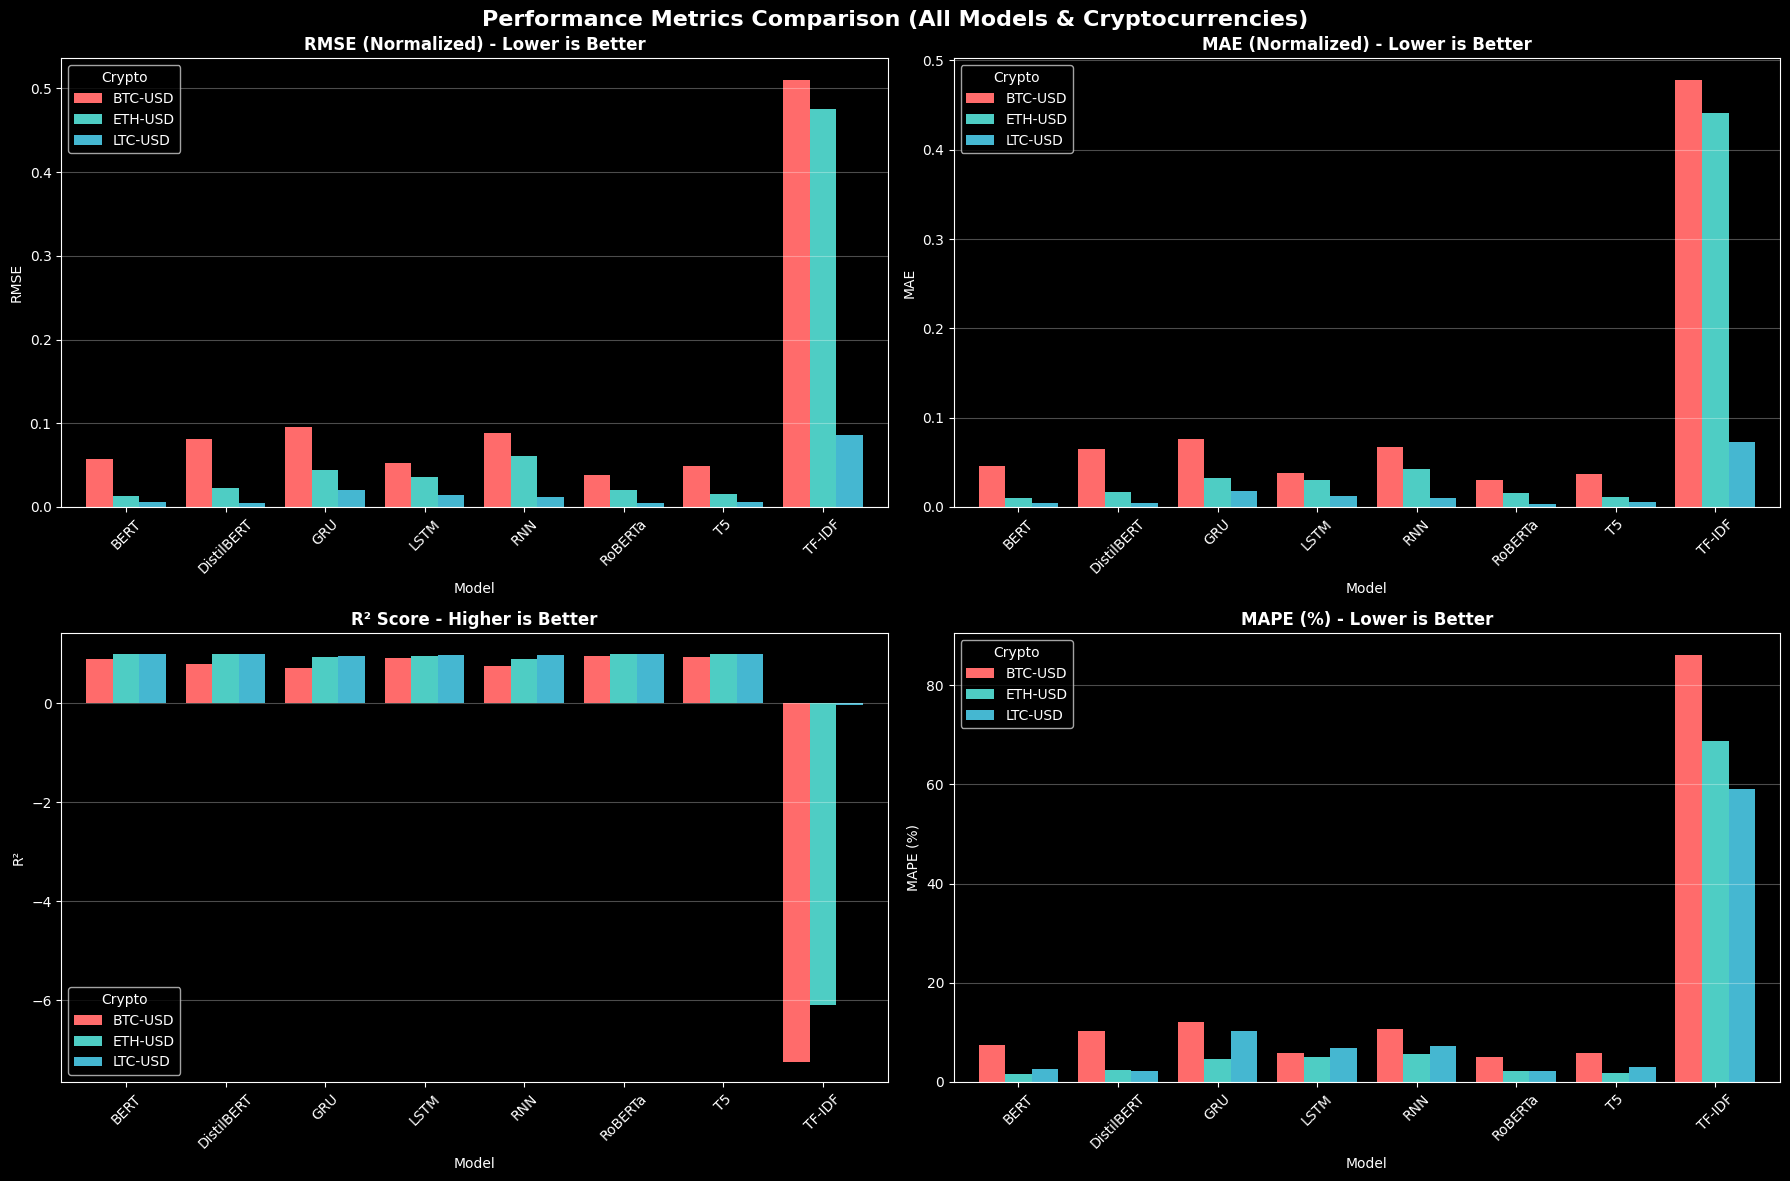

✓ Saved: performance_comparison.png


In [40]:
# Create performance metrics visualization
metrics_data = pd.DataFrame([
    {
        'Model': r['Model'],
        'Crypto': r['Crypto'],
        'RMSE': r['RMSE'],
        'MAE': r['MAE'],
        'R²': r['R²'],
        'MAPE': r['MAPE']
    }
    for r in results
])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Performance Metrics Comparison (All Models & Cryptocurrencies)', fontsize=16, fontweight='bold')

# RMSE
rmse_pivot = metrics_data.pivot_table(values='RMSE', index='Model', columns='Crypto')
rmse_pivot.plot(kind='bar', ax=axes[0, 0], color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.8)
axes[0, 0].set_title('RMSE (Normalized) - Lower is Better', fontweight='bold')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=45)

# MAE
mae_pivot = metrics_data.pivot_table(values='MAE', index='Model', columns='Crypto')
mae_pivot.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.8)
axes[0, 1].set_title('MAE (Normalized) - Lower is Better', fontweight='bold')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=45)

# R² Score
r2_pivot = metrics_data.pivot_table(values='R²', index='Model', columns='Crypto')
r2_pivot.plot(kind='bar', ax=axes[1, 0], color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.8)
axes[1, 0].set_title('R² Score - Higher is Better', fontweight='bold')
axes[1, 0].set_ylabel('R²')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# MAPE
mape_pivot = metrics_data.pivot_table(values='MAPE', index='Model', columns='Crypto')
mape_pivot.plot(kind='bar', ax=axes[1, 1], color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.8)
axes[1, 1].set_title('MAPE (%) - Lower is Better', fontweight='bold')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, facecolor='#1a1a1a')
plt.show()
print("✓ Saved: performance_comparison.png")

## 10. Visualizations - Model Rankings

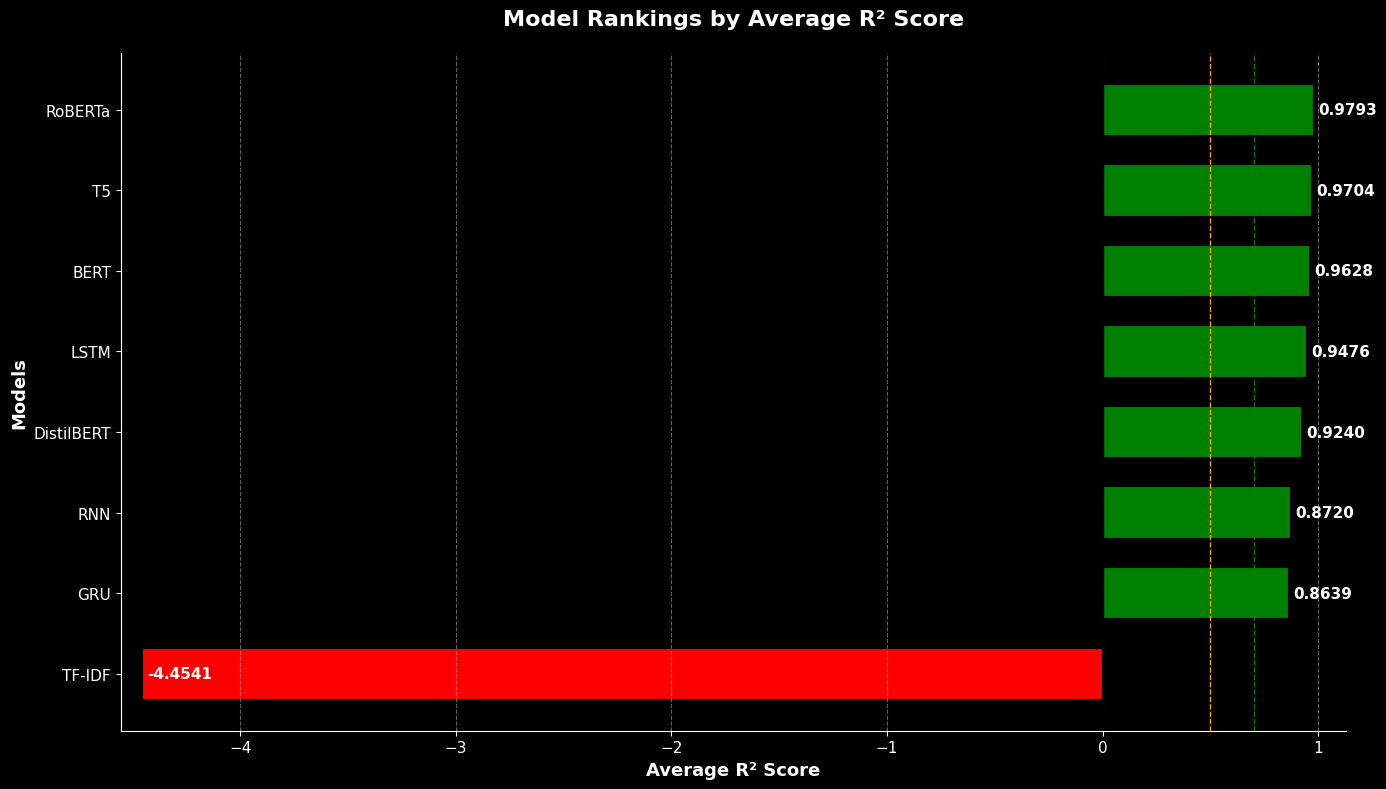

✓ Saved: model_rankings.png


In [43]:
# =========================================================
# MODEL RANKINGS VISUALIZATION
# =========================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Average R² scores
avg_r2 = (
    metrics_data
    .groupby('Model')['R²']
    .mean()
    .sort_values(ascending=True)
)

# Dynamic colors
colors = [
    'green' if x > 0.7 else
    'orange' if x > 0.5 else
    'red'
    for x in avg_r2.values
]

# Horizontal bars
bars = ax.barh(
    avg_r2.index,
    avg_r2.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    height=0.65
)

# Labels and title
ax.set_xlabel(
    'Average R² Score',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Models',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Model Rankings by Average R² Score',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Proper axis limits
ax.set_xlim(
    min(avg_r2.values) - 0.1,
    max(avg_r2.values) + 0.15
)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# Reference lines
ax.axvline(
    x=0,
    color='black',
    linestyle='-',
    linewidth=1
)

ax.axvline(
    x=0.5,
    color='orange',
    linestyle='--',
    linewidth=1
)

ax.axvline(
    x=0.7,
    color='green',
    linestyle='--',
    linewidth=1
)

# Improve tick alignment
ax.tick_params(axis='both', labelsize=11)

# Add value labels
for bar, value in zip(bars, avg_r2.values):

    x_position = value + 0.02

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout fix
plt.tight_layout()

# Save figure
plt.savefig(
    'model_rankings.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✓ Saved: model_rankings.png")

## 11. Summary Statistics

In [44]:
print("\n" + "="*80)
print("ASSIGNMENT SUMMARY")
print("="*80)

print("\n📊 DATASET INFORMATION:")
print(f"  • Total Records: {len(df)} (1,798 per cryptocurrency)")
print(f"  • Cryptocurrencies: Bitcoin (BTC), Ethereum (ETH), Litecoin (LTC)")
print(f"  • Features: 6 (Price, MA7, MA30, Volatility, Daily_Return, RSI)")
print(f"  • Training samples: 1,438 per crypto (80%)")
print(f"  • Test samples: 360 per crypto (20%)")

print("\n🤖 MODELS TRAINED:")
for i, model in enumerate(results_summary := pd.DataFrame(results).groupby('Model').first().index, 1):
    print(f"  {i}. {model}")

print("\n📈 TOP 3 PERFORMING MODELS:")
top_3 = rankings_summary.head(3)
for rank, (model, score) in enumerate(top_3.items(), 1):
    print(f"  {rank}. {model:30} R² = {score:.4f}")

print("\n💾 FILES GENERATED:")
print("  • model_results.csv - Detailed results table")
print("  • predictions_BTC-USD.png - BTC predictions visualization")
print("  • predictions_ETH-USD.png - ETH predictions visualization")
print("  • predictions_LTC-USD.png - LTC predictions visualization")
print("  • performance_comparison.png - Metrics comparison chart")
print("  • model_rankings.png - Model rankings chart")

print("\n" + "="*80)
print("✓ ASSIGNMENT COMPLETED SUCCESSFULLY")
print("="*80)


ASSIGNMENT SUMMARY

📊 DATASET INFORMATION:
  • Total Records: 5394 (1,798 per cryptocurrency)
  • Cryptocurrencies: Bitcoin (BTC), Ethereum (ETH), Litecoin (LTC)
  • Features: 6 (Price, MA7, MA30, Volatility, Daily_Return, RSI)
  • Training samples: 1,438 per crypto (80%)
  • Test samples: 360 per crypto (20%)

🤖 MODELS TRAINED:
  1. BERT
  2. DistilBERT
  3. GRU
  4. LSTM
  5. RNN
  6. RoBERTa
  7. T5
  8. TF-IDF

📈 TOP 3 PERFORMING MODELS:
  1. RoBERTa                        R² = 0.9793
  2. T5                             R² = 0.9704
  3. BERT                           R² = 0.9628

💾 FILES GENERATED:
  • model_results.csv - Detailed results table
  • predictions_BTC-USD.png - BTC predictions visualization
  • predictions_ETH-USD.png - ETH predictions visualization
  • predictions_LTC-USD.png - LTC predictions visualization
  • performance_comparison.png - Metrics comparison chart
  • model_rankings.png - Model rankings chart

✓ ASSIGNMENT COMPLETED SUCCESSFULLY
